In [1]:
#1) Caricamento e controllo iniziale del dataset
import pandas as pd

# Caricamento del dataset
df = pd.read_csv('natural_disaster_human_mobility.csv')

# Ispezione iniziale
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4686154 entries, 0 to 4686153
Data columns (total 5 columns):
 #   Column          Dtype  
---  ------          -----  
 0   disaster.event  object 
 1   user.anon       int64  
 2   latitude        float64
 3   longitude.anon  float64
 4   time            object 
dtypes: float64(2), int64(1), object(2)
memory usage: 178.8+ MB


In [2]:
#2) Pulizia dei dati
# Rimozione righe senza user.anon
df = df.dropna(subset=['user.anon'])

# Creazione flag per valori mancanti in lat, lon o time
df['na_flag'] = df[['latitude', 'longitude.anon', 'time']].isna().any(axis=1)

# Aggregazione per utente per contare valori mancanti
agg_na = df.groupby('user.anon')['na_flag'].sum().reset_index()

# Manteniamo solo utenti senza valori mancanti (teniamo solo utenti che hanno dati completi)
valid_users = agg_na[agg_na['na_flag'] == 0]['user.anon']
df = df[df['user.anon'].isin(valid_users)].copy()

# Rimozione colonna temporanea
df.drop(columns=['na_flag'], inplace=True)

# Rimozione dei duplicati
df = df.drop_duplicates()

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4367517 entries, 0 to 4686153
Data columns (total 5 columns):
 #   Column          Dtype  
---  ------          -----  
 0   disaster.event  object 
 1   user.anon       int64  
 2   latitude        float64
 3   longitude.anon  float64
 4   time            object 
dtypes: float64(2), int64(1), object(2)
memory usage: 199.9+ MB


In [3]:
#3) Correzione dei nomi delle colonne per latitudine e longitudine
#Nel dataset originale, latitudine e longitudine erano invertite
df = df.rename(columns={
    'latitude':'longitude',
    'longitude.anon':'latitude'
})

df[['latitude','longitude']].head()

,latitude,longitude
0,24.515364,139.742561
1,24.569996,139.702880
2,24.550507,139.701482
3,24.508685,139.728029
4,24.576521,139.702315


In [4]:
#4) Pre-elaborazione temporale
#Conversione della colonna "time" in formato datetime - Valori non convertibili diventano NaT
df["time"] = pd.to_datetime(df["time"], errors='coerce')

#Rimozione delle righe con valori NaT nella colonna "time"
df = df.dropna(subset=["time"])

#Ordinamento dei dati in ordine cronologico 
df = df.sort_values(by="time")

#Estrazione informazioni temporali
df["date"] = df["time"].dt.date #estraggo l'oggetto date (utile per raggruppamenti giornalieri)
df["hour"] = df["time"].dt.hour #utile per analisi orarie

df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4367516 entries, 1007249 to 1592379
Data columns (total 7 columns):
 #   Column          Dtype         
---  ------          -----         
 0   disaster.event  object        
 1   user.anon       int64         
 2   longitude       float64       
 3   latitude        float64       
 4   time            datetime64[ns]
 5   date            object        
 6   hour            int32         
dtypes: datetime64[ns](1), float64(2), int32(1), int64(1), object(2)
memory usage: 249.9+ MB


In [5]:
#5) Aggregazioni per evento
#Numero di utenti unici per evento
agg_user = df.groupby('disaster.event')['user.anon'].nunique().reset_index()
agg_user.rename(columns={'user.anon': 'num_user'}, inplace=True)

#Numero totale di tweet per evento
agg_event = df.groupby('disaster.event').size().reset_index(name='num_tweets')

#Merge delle due aggregazioni in un unico DataFrame per avere una visione completa per evento
merged = pd.merge(agg_user, agg_event, on='disaster.event')

#Visualizzzazione del risultato
print(merged)

        disaster.event  num_user  num_tweets
0             01_Wipha     74724     1416223
1            02_Halong      5244      171134
2          06_Kalmaegi      1375       43200
3   08_Rammasun_Manila     35322      816317
4             12_Bohol      7942      114537
5           13_Iquique      1470       15287
6              14_Napa      1850       37998
7           21_Norfolk      8498      114999
8           22_Hamburg      2745       15050
9           23_Atlanta     15783      157034
10          31_Phoenix     23132      579150
11          32_Detroit     15949      453832
12        33_Baltimore     14582      328408
13          41_AuFire1      4829       40016
14          42_AuFire2      7845       64331


In [6]:
#6) Orizzonte temporale dei tweet per evento
for event in df["disaster.event"].unique():
    event_data = df[df["disaster.event"] == event]
    first_time = event_data["time"].min()
    last_time = event_data["time"].max()
    print(f"Evento: {event}, Primo istante: {first_time}, Ultimo istante: {last_time}") 
    

Evento: 01_Wipha, Primo istante: 2013-09-30 03:00:01, Ultimo istante: 2013-11-07 02:59:59
Evento: 12_Bohol, Primo istante: 2013-09-30 03:03:19, Ultimo istante: 2013-10-31 02:59:45
Evento: 41_AuFire1, Primo istante: 2013-10-08 03:04:35, Ultimo istante: 2013-11-10 02:51:13
Evento: 42_AuFire2, Primo istante: 2013-10-08 03:09:04, Ultimo istante: 2013-11-10 02:49:31
Evento: 21_Norfolk, Primo istante: 2013-11-20 05:00:41, Ultimo istante: 2013-12-21 02:52:36
Evento: 22_Hamburg, Primo istante: 2013-11-20 06:11:24, Ultimo istante: 2013-12-21 02:58:44
Evento: 23_Atlanta, Primo istante: 2014-01-08 03:00:08, Ultimo istante: 2014-02-14 02:59:52
Evento: 13_Iquique, Primo istante: 2014-03-17 12:09:38, Ultimo istante: 2014-04-17 02:52:30
Evento: 08_Rammasun_Manila, Primo istante: 2014-06-07 03:00:02, Ultimo istante: 2014-08-03 02:59:59
Evento: 02_Halong, Primo istante: 2014-07-22 03:00:21, Ultimo istante: 2014-08-25 02:59:39
Evento: 33_Baltimore, Primo istante: 2014-07-28 03:00:44, Ultimo istante: 201

In [7]:
#7) Selezione di un evento specifico per analisi dettagliata
selected_event='14_Napa'  #Sostituire con l'evento di interesse

#Creazione di un dataframe contenente solo i tweet relativi all'evento selezionato
df_event = df[df['disaster.event']== selected_event]

#Numero totale di tweet per l'evento selezionato
len(df_event)

37998

In [8]:
#8) Calcolo dei tweet giornalieri per l'evento selezionato
daily = df_event.groupby('date').size()

daily.head()

date
2014-07-30    1110
2014-07-31    1168
2014-08-01    1164
2014-08-02    1027
2014-08-03    1331
dtype: int64

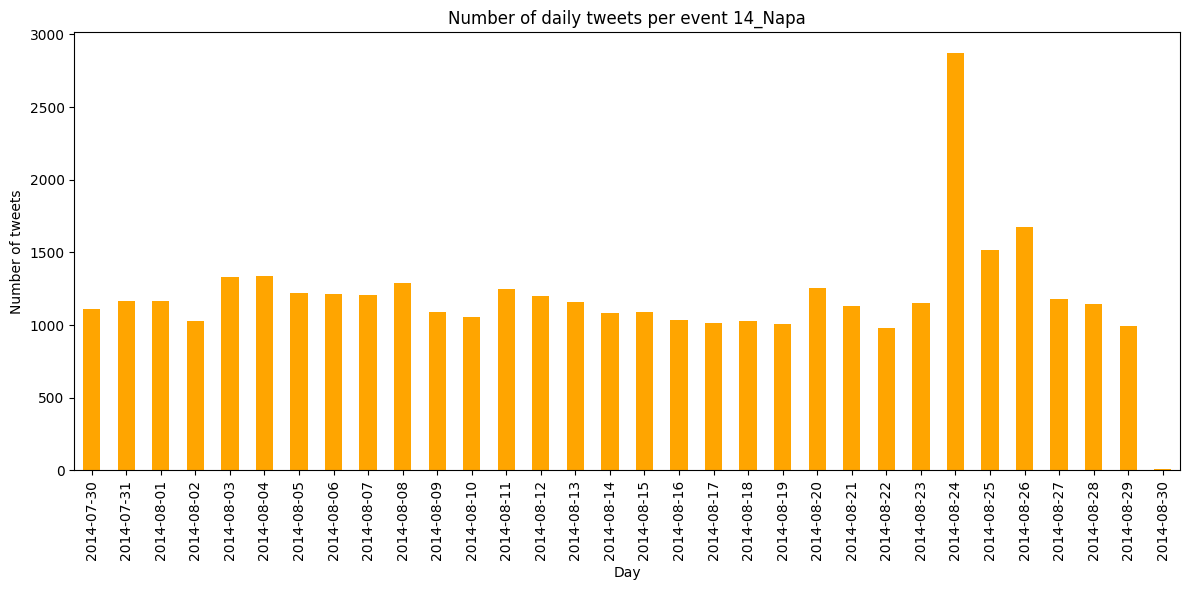

In [9]:
#Visualizzazione numero di tweet giornalieri 
import matplotlib.pyplot as plt

#Creazione grafico a barre per visualizzare il numero di tweet giornalieri 
plt.figure(figsize=(12,6))
daily.plot(kind='bar', color='orange')
plt.title(f"Number of daily tweets per event {selected_event}")
plt.xlabel("Day")
plt.ylabel("Number of tweets")
plt.tight_layout()
plt.show()


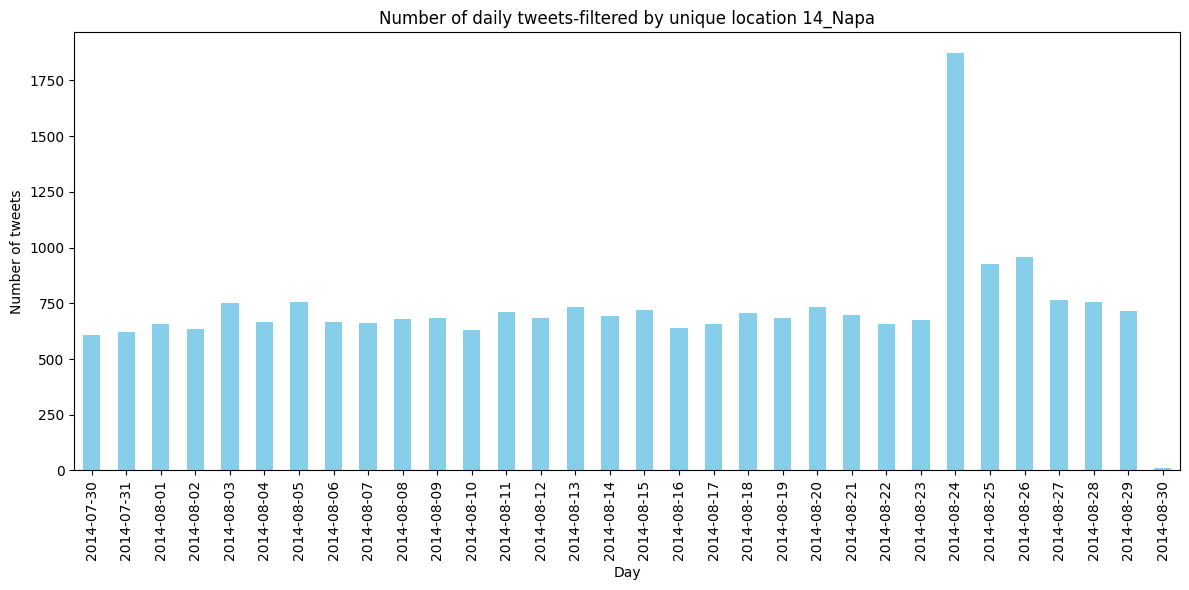

Tweet originali: 37998
Tweet dopo filtro mobilità: 23011


In [10]:
#9) Filtraggio dei tweet duplicati per utente, data e posizione

#lat/long arrotondate per gestire piccole fluttuazioni del GPS 
df['lat_round'] = df['latitude'].round(4)
df['lon_round'] = df['longitude'].round(4)

#Rimozione dei tweet duplicati per utente, giorno e posizione
df_filtered = df.drop_duplicates(subset=['user.anon', 'date', 'lat_round', 'lon_round']).copy()

#Ricalcolo del numero di tweet giornalieri filtrati per l'evento selezionato
daily_filtered = df_filtered[df_filtered['disaster.event'] == selected_event].groupby('date').size()

#Di nuovo grafico a barre per visualizzare il numero di tweet giornalieri dopo il filtraggio
plt.figure(figsize=(12,6))
daily_filtered.plot(kind='bar', color='skyblue')
plt.title(f"Number of daily tweets-filtered by unique location {selected_event}")
plt.xlabel("Day")
plt.ylabel("Number of tweets")
plt.tight_layout()
plt.show()

print(f"Tweet originali: {len(df_event)}")
print(f"Tweet dopo filtro mobilità: {len(df_filtered[df_filtered['disaster.event'] == selected_event])}")


In [11]:
#10) Segmentazione temporale (Prims/Durante/Dopo) dei tweet per ciascun evento

#Dizionario con le finestre temporali dei disastri (start/end)
disaster_windows = {
    '14_Napa': {
        'start': pd.to_datetime('2014-08-24 00:00:00'), 
        'end': pd.to_datetime('2014-08-24 23:59:59')    
    },
    '01_Wipha': {
        'start': pd.to_datetime('2013-10-09 00:00:00'),
        'end': pd.to_datetime('2013-10-22 23:59:59')
    },

    '02_Halong': {
        'start': pd.to_datetime('2014-07-27 00:00:00'),
        'end': pd.to_datetime('2014-08-18 23:59:59')
    },

    '06_Kalmaegi': {
        'start': pd.to_datetime('2014-09-11 00:00:00'),
        'end': pd.to_datetime('2014-09-18 23:59:59')
    },

    '08_Rammasun_Manila': {
        'start': pd.to_datetime('2014-07-11 00:00:00'),
        'end': pd.to_datetime('2014-07-20 23:59:59')
    },

    '12_Bohol': {
        'start': pd.to_datetime('2013-10-15 00:00:00'), 
        'end': pd.to_datetime('2013-10-15 23:59:59')    
    },

    '13_Iquique': {
        'start': pd.to_datetime('2014-04-01 00:00:00'), 
        'end': pd.to_datetime('2014-04-01 23:59:59')   
    },

    '41_AuFire1': {
        'start': pd.to_datetime('2013-10-17 00:00:00'), 
        'end': pd.to_datetime('2013-10-22 23:59:59')    
    },

    '42_AuFire2': {
        'start': pd.to_datetime('2013-10-23 00:00:00'), 
        'end': pd.to_datetime('2013-10-28 23:59:59')    
    },

    '21_Norfolk': {
        'start': pd.to_datetime('2013-12-04 00:00:00'), 
        'end': pd.to_datetime('2013-12-07 23:59:59')    
    },

    '22_Hamburg': {
        'start': pd.to_datetime('2013-12-05 00:00:00'), 
        'end': pd.to_datetime('2013-12-07 23:59:59')    
    },

    '23_Atlanta': {
        'start': pd.to_datetime('2014-01-28 00:00:00'), 
        'end': pd.to_datetime('2014-01-30 23:59:59')    
    },
    
    '33_Baltimore': {
        'start': pd.to_datetime('2014-08-12 00:00:00'), 
        'end': pd.to_datetime('2014-08-15 23:59:59')    
    },

    '32_Detroit': {
        'start': pd.to_datetime('2014-08-18 00:00:00'), 
        'end': pd.to_datetime('2014-08-21 23:59:59')    
    },

    '31_Phoenix': {
        'start': pd.to_datetime('2014-09-07 00:00:00'), 
        'end': pd.to_datetime('2014-09-09 23:59:59')    
    }
}

#Funzione per assegnare la fase temporale a ciascun tweet
def get_disaster_phase(row):
    event = row['disaster.event']
    if event in disaster_windows:
        start = disaster_windows[event]['start']
        end = disaster_windows[event]['end']
        
        if row['time'] < start:
            return 'Before'
        elif row['time'] <= end:
            return 'During'
        else:
            return 'After'

#Creazione della colonna 'phase' nel dataframe filtrato
df_filtered['phase'] = df_filtered.apply(get_disaster_phase, axis=1)

#Verifica della distribuzione delle fasi per l'evento selezionato
print(df_filtered[df_filtered['disaster.event'] == selected_event]['phase'].value_counts())

phase
Before    17006
After      4133
During     1872
Name: count, dtype: int64


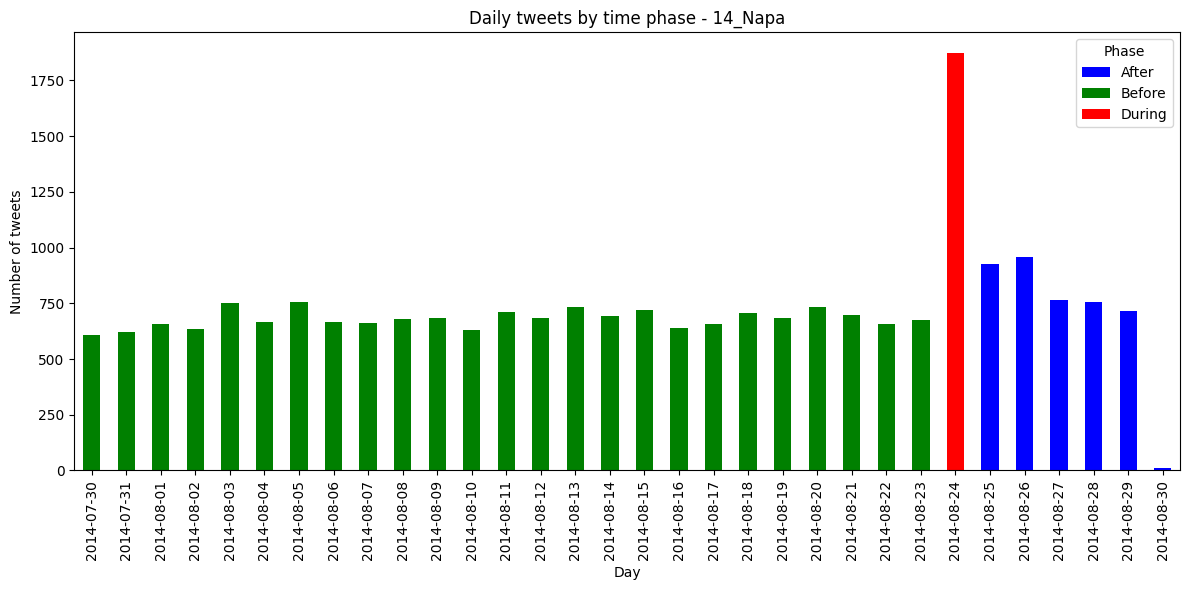

In [12]:
# Grafico a barre dei tweet giornalieri divisi per fase temporale

#Filtro solo i tweet dell'evento selezionato
df_event_filtered = df_filtered[df_filtered['disaster.event'] == selected_event].copy()

#Creo una tabella pivot con date come indice e fasi come colonne, conteggio dei tweet
daily_phase = df_event_filtered.pivot_table(index='date', columns='phase', aggfunc='size', fill_value=0)

phase_colors = {'Before': 'green', 'During': 'red', 'After': 'blue'}

daily_phase.plot(kind='bar', stacked=True, color=[phase_colors[phase] for phase in daily_phase.columns], figsize=(12,6))

plt.title(f"Daily tweets by time phase - {selected_event}")
plt.xlabel("Day")
plt.ylabel("Number of tweets")
plt.legend(title='Phase')
plt.tight_layout()
plt.show()

In [ ]:
"""window = disaster_windows[selected_event]

start = window['start']
end = window['end']

before_start = start - pd.Timedelta(days=6)
before_end = start - pd.Timedelta(seconds=1)

def get_phase_single_event(row):
    if row['disaster.event'] != selected_event:
        return None  # oppure la tua funzione originale
    
    if before_start <= row['time'] <= before_end:
        return 'Before'
    elif start <= row['time'] <= end:
        return 'During'
    elif row['time'] > end:
        return 'After'
    else:
        return None  # tutto ciò che è prima dei 6 giorni viene scartato 

df_event = df_filtered[df_filtered['disaster.event'] == selected_event].copy()

df_event['phase'] = df_event.apply(get_phase_single_event, axis=1)

#Tenere solo le righe con fase valida
df_event = df_event[df_event['phase'].notna()]"""

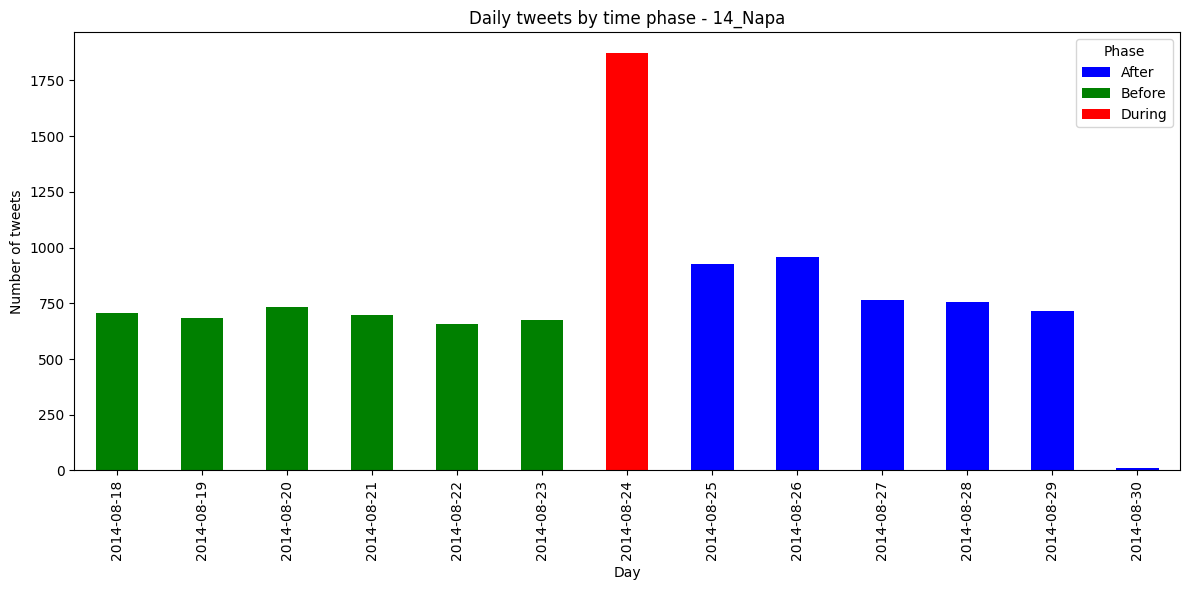

In [ ]:
"""
# Grafico a barre dei tweet giornalieri divisi per fase temporale

#Filtrare solo i tweet dell'evento selezionato
df_event_filtered = df_event[df_event['disaster.event'] == selected_event].copy()

daily_phase = df_event_filtered.pivot_table(index='date', columns='phase', aggfunc='size', fill_value=0)

phase_colors = {'Before': 'green', 'During': 'red', 'After': 'blue'}

daily_phase.plot(kind='bar', stacked=True, color=[phase_colors[phase] for phase in daily_phase.columns], figsize=(12,6))

plt.title(f"Daily tweets by time phase - {selected_event}")
plt.xlabel("Day")
plt.ylabel("Number of tweets")
plt.legend(title='Phase')
plt.tight_layout()
plt.show()"""


In [ ]:
"""
#11) Clustering spaziale con DBSCAN per l'evento selezionato e la fase selezionata

import numpy as np
from sklearn.cluster import DBSCAN

#Parametri - evento e fase 
event_name = selected_event
phase_name = 'Before'  #Sostituire con la fase di interesse (Before, During, After)

#Raggio terrestre in km per conversione da radianti
kms_per_radian = 6371.0088

#Parametri per DBSCAN
distanza_km =   0.6
min_samples =  10

#Filtraggio dati per clustering
df_cluster = df_event[
    (df_event['disaster.event'] == event_name) &
    (df_event['phase'] == phase_name)
].copy()

print("Numero punti:", len(df_cluster))

if len(df_cluster) < min_samples:
    raise ValueError("Troppi pochi dati per DBSCAN")

#Conversione delle coordinate in radianti per DBSCAN con metrica Haversine
coords_rad = np.radians(df_cluster[['latitude', 'longitude']].values)

#Conversione parametro epsilon da km a radianti
eps_rad = distanza_km / kms_per_radian

print(f"Epsilon (radianti): {eps_rad}")
print(f"Epsilon (km): {distanza_km}")

#DBSCAN
db = DBSCAN(
    eps=eps_rad,
    min_samples=min_samples,
    metric='haversine',
    algorithm='ball_tree'
)

#Esecuzione del clustering
labels = db.fit_predict(coords_rad)
df_cluster['cluster_id'] = labels

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)

print("\nRisultati:")
print(f"Cluster trovati: {n_clusters}")
print(f"Rumore: {n_noise}")
"""

Numero punti: 4155
Epsilon (radianti): 9.417660826335697e-05
Epsilon (km): 0.6

Risultati:
Cluster trovati: 9
Rumore: 75


In [18]:
#11) Clustering spaziale con DBSCAN per l'evento selezionato e la fase selezionata

import numpy as np
from sklearn.cluster import DBSCAN

#Parametri - evento e fase 
event_name = selected_event
phase_name = 'During'  #Sostituire con la fase di interesse (Before, During, After)

#Raggio terrestre in km per conversione da radianti
kms_per_radian = 6371.0088

#Parametri per DBSCAN
distanza_km =  0.6
min_samples =  10

#Filtraggio dati per clustering
df_cluster = df_filtered[
    (df_filtered['disaster.event'] == event_name) &
    (df_filtered['phase'] == phase_name)
].copy()

print("Numero punti:", len(df_cluster))

if len(df_cluster) < min_samples:
    raise ValueError("Troppi pochi dati per DBSCAN")

#Conversione delle coordinate in radianti per DBSCAN con metrica Haversine
coords_rad = np.radians(df_cluster[['latitude', 'longitude']].values)

#Conversione parametro epsilon da km a radianti
eps_rad = distanza_km / kms_per_radian

print(f"Epsilon (radianti): {eps_rad}")
print(f"Epsilon (km): {distanza_km}")

#DBSCAN
db = DBSCAN(
    eps=eps_rad,
    min_samples=min_samples,
    metric='haversine',
    algorithm='ball_tree'
)

#Esecuzione del clustering
labels = db.fit_predict(coords_rad)
df_cluster['cluster_id'] = labels

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)

print("\nRisultati:")
print(f"Cluster trovati: {n_clusters}")
print(f"Rumore: {n_noise}")

Numero punti: 1872
Epsilon (radianti): 9.417660826335697e-05
Epsilon (km): 0.6

Risultati:
Cluster trovati: 9
Rumore: 74


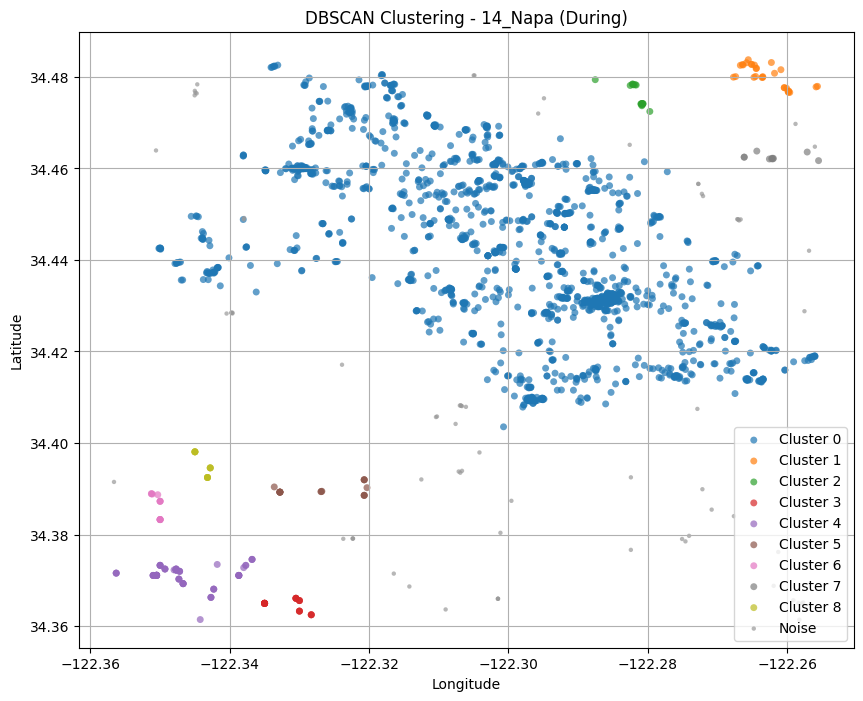

In [19]:
#12) Visualizzazione dei cluster spaziali
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 8))

labels = df_cluster['cluster_id'].values
unique_labels = set(labels)

#Generazione colori distinti per i cluster (escluso il rumore)
colors = plt.cm.tab10(np.linspace(0, 1, len(unique_labels))) 

for k, col in zip(unique_labels, colors):
    
    if k == -1:
        col = [0.6, 0.6, 0.6, 0.6]
        label = 'Noise'
        size = 10
    else:
        label = f'Cluster {k}' 
        size = 25

    mask = labels == k
    xy = df_cluster[mask]

    plt.scatter(
        xy['longitude'],
        xy['latitude'],
        c=[col],
        label=label,
        s=size,
        alpha=0.7,
        edgecolors='none'
    )

plt.title(f'DBSCAN Clustering - {event_name} ({phase_name})')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend()
plt.grid(True)
plt.show()

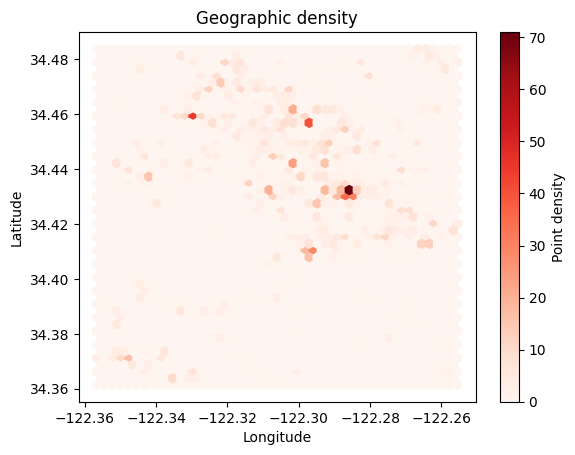

In [20]:
plt.hexbin(
    df_cluster['longitude'],
    df_cluster['latitude'],
    gridsize=45,
    cmap='Reds'
)
plt.colorbar(label='Point density')
plt.title('Geographic density')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.show()

In [21]:
import numpy as np
from sklearn.cluster import DBSCAN

#DBSCAN eseguito come prima
labels = db.fit_predict(coords_rad)
df_cluster['cluster_id'] = labels

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)

print("\nRisultati:")
print(f"Cluster trovati: {n_clusters}")
print(f"Rumore: {n_noise}")

#Percentuale di rumore
percent_noise = n_noise / len(df_cluster) * 100
print(f"Percentuale di rumore: {percent_noise:.2f}%")

#Dettagli cluster: numero punti, percentuale, densità
print("\nDettagli per cluster:")
print(f"{'Cluster':>7} | {'Punti':>6} | {'% Punti':>7} | {'Raggio max (km)':>14} | {'Densità (punti/km²)':>20}")
print("-"*65)

for cluster_id in set(labels):
    if cluster_id == -1:
        continue  # saltare il rumore
    
    cluster_points = df_cluster[df_cluster['cluster_id'] == cluster_id][['latitude', 'longitude']].values
    num_points = len(cluster_points)
    
    #Percentuale di punti sul totale
    percent_points = num_points / len(df_cluster) * 100
    
    #Calcolo centroide del cluster
    centroid = cluster_points.mean(axis=0)
    
    #Distanza massima dal centroide 
    distances_km = kms_per_radian * np.arccos(
        np.sin(np.radians(centroid[0])) * np.sin(np.radians(cluster_points[:,0])) +
        np.cos(np.radians(centroid[0])) * np.cos(np.radians(cluster_points[:,0])) *
        np.cos(np.radians(cluster_points[:,1]) - np.radians(centroid[1]))
    )
    max_radius = distances_km.max()
    

    area = np.pi * max_radius**2
    density = num_points / area if area > 0 else np.nan
    
    print(f"{cluster_id:7d} | {num_points:6d} | {percent_points:7.2f}% | {max_radius:14.3f} | {density:20.3f}")


Risultati:
Cluster trovati: 9
Rumore: 74
Percentuale di rumore: 3.95%

Dettagli per cluster:
Cluster |  Punti | % Punti | Raggio max (km) |  Densità (punti/km²)
-----------------------------------------------------------------
      0 |   1612 |   86.11% |          5.482 |               17.074
      1 |     30 |    1.60% |          0.705 |               19.191
      2 |     17 |    0.91% |          0.678 |               11.777
      3 |     23 |    1.23% |          0.423 |               40.940
      4 |     66 |    3.53% |          1.101 |               17.335
      5 |     17 |    0.91% |          0.630 |               13.645
      6 |     12 |    0.64% |          0.321 |               36.986
      7 |     10 |    0.53% |          0.605 |                8.704
      8 |     11 |    0.59% |          0.355 |               27.781


In [22]:
#13) Clustering con K-Means per confronto con DBSCAN
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

#assegno come numero di cluster quello trovato da DBSCAN
n_clusters_dbscan = len(set(df_cluster['cluster_id'])) - (1 if -1 in df_cluster['cluster_id'].values else 0)

print(f"Numero cluster da DBSCAN: {n_clusters_dbscan}")

if n_clusters_dbscan <= 1:
    raise ValueError("DBSCAN ha trovato troppo pochi cluster per confronto con KMeans")


#Preparazione dei dati - estrazione delle coordinate e standardizzazione
coords = df_cluster[['latitude', 'longitude']].values

scaler = StandardScaler()
coords_scaled = scaler.fit_transform(coords)

#Applicazione K-Means
kmeans = KMeans(
    n_clusters=n_clusters_dbscan,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(coords_scaled)

#Salvataggio dei risultati di K-Means nel dataframe per confronto
df_cluster['kmeans_cluster'] = kmeans_labels

Numero cluster da DBSCAN: 9


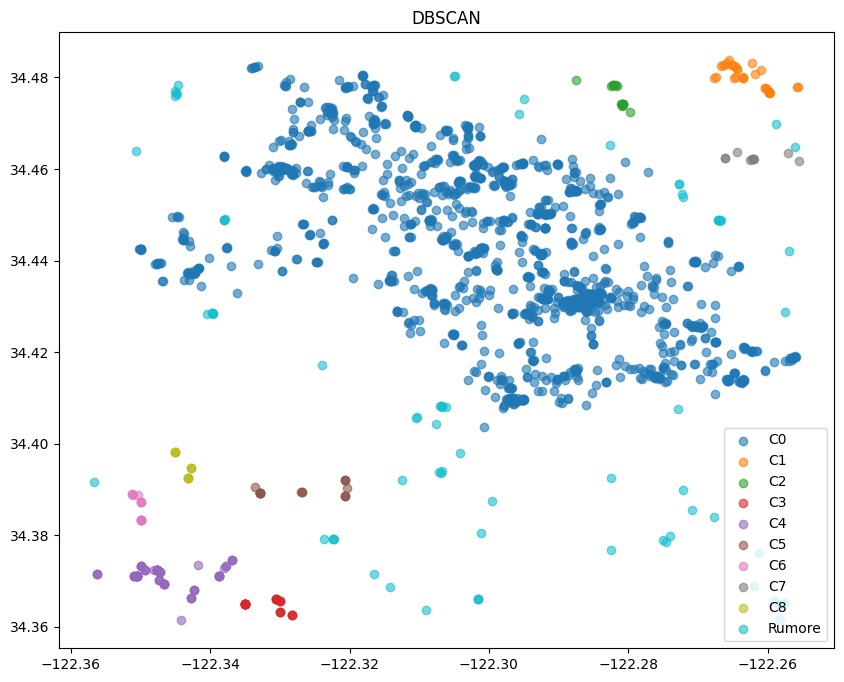

In [23]:
plt.figure(figsize=(10,8))

for k in set(df_cluster['cluster_id']):
    
    if k == -1:
        col = 'lightgray'
        label = 'Rumore'
    else:
        col = None
        label = f'C{k}'
    
    mask = df_cluster['cluster_id'] == k
    
    plt.scatter(
        df_cluster[mask]['longitude'],
        df_cluster[mask]['latitude'],
        label=label,
        alpha=0.6
    )

plt.title("DBSCAN")
plt.legend()
plt.show()

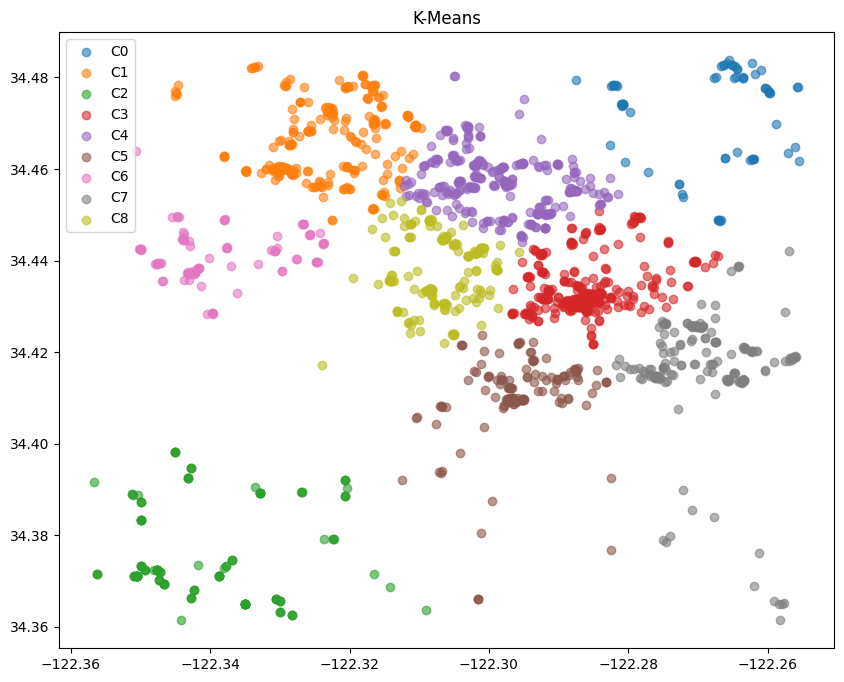

In [24]:
plt.figure(figsize=(10,8))

for k in set(df_cluster['kmeans_cluster']):
    
    mask = df_cluster['kmeans_cluster'] == k
    
    plt.scatter(
        df_cluster[mask]['longitude'],
        df_cluster[mask]['latitude'],
        label=f'C{k}',
        alpha=0.6
    )

plt.title("K-Means")
plt.legend()
plt.show()

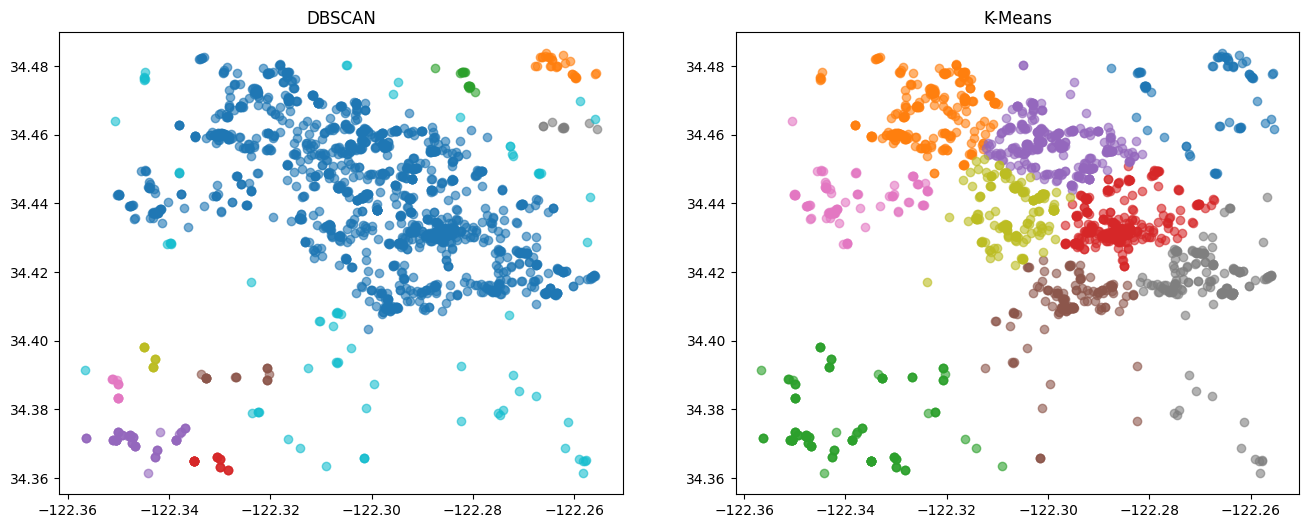

In [25]:
#14) Confronto visivo dei cluster DBSCAN vs K-Means
fig, axes = plt.subplots(1, 2, figsize=(16,6))

#DBSCAN
for k in set(df_cluster['cluster_id']):
    mask = df_cluster['cluster_id'] == k
    axes[0].scatter(
        df_cluster[mask]['longitude'],
        df_cluster[mask]['latitude'],
        alpha=0.6
    )

axes[0].set_title("DBSCAN")

#KMEANS
for k in set(df_cluster['kmeans_cluster']):
    mask = df_cluster['kmeans_cluster'] == k
    axes[1].scatter(
        df_cluster[mask]['longitude'],
        df_cluster[mask]['latitude'],
        alpha=0.6
    )

axes[1].set_title("K-Means")

plt.show()

In [26]:
#15) Valutazione K-Means con silhouette score
from sklearn.metrics import silhouette_score

#Calcolo silhouette score 
score = silhouette_score(coords_scaled, kmeans_labels)
print("Silhouette KMeans:", score)

Silhouette KMeans: 0.4837962307621037
